# HPC Usage Statistics: Infrastructure Perspective

This notebook visualises HPC cluster usage from an **infrastructure perspective**, focusing on **weighted efficiency metrics**. Weighted efficiency answers: "How efficiently are allocated resources being used overall?" — larger jobs contribute more because they consume more cluster capacity.

**Use this notebook for:**
- Capacity planning and resource allocation decisions
- Identifying which faculties/users have the largest impact on cluster utilisation
- Quantifying total resource waste in absolute terms

For a user-focused view (average efficiency, where each job counts equally), see `visualisation_users.ipynb`.

**Sections:**
1. [Overview](#1.-Overview) - Basic resource usage metrics by faculty
2. [Global Stats](#2.-Global-Stats) - Key metrics at a glance
3. [Detailed Analysis](#3.-Detailed-Analysis) - Comprehensive charts and comparisons
4. [Correlation Analysis](#4.-Correlation-Analysis) - Relationships between metrics
5. [Technical Appendix](#5.-Technical-Appendix) - Methodology and raw data

In [1]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# Configuration: This notebook uses WEIGHTED efficiency
EFFICIENCY_TYPE = 'weighted'
CPU_EFF_COL = 'weighted_cpu_eff_req'
MEM_EFF_COL = 'weighted_mem_eff'
TIME_EFF_COL = 'weighted_time_eff'
NOTEBOOK_TITLE = 'Infrastructure Perspective'

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load data
FACULTY_STATS_PATH = "../results/hpc_stats_output.csv"
JOB_LEVEL_PATH = "../results/job_level_metrics.csv"

df = pd.read_csv(FACULTY_STATS_PATH)
df['faculty'] = df['faculty'].str.strip('"')
df_faculties = df[df['faculty'] != 'all'].copy()
df_global = df[df['faculty'] == 'all'].copy()

# Convert NULL strings to NaN
df_faculties = df_faculties.replace('NULL', np.nan)
for col in df_faculties.columns:
    if col != 'faculty':
        df_faculties[col] = pd.to_numeric(df_faculties[col], errors='coerce')

# Faculty name mapping: merge historically different names for the same faculty
FACULTY_MERGE = {
    "Faculty of Life Sciences and Medicine": "Faculty of Life Sciences & Medicine",
    "IoPPN": "Institute of Psychiatry, Psychology & Neuroscience",
    "Dentistry, Oral & Craniofacial Sciences": "Faculty of Dentistry, Oral & Craniofacial Sciences",
    "Social Science & Public Policy": "Faculty of Social Science & Public Policy",
}

df_faculties['faculty'] = df_faculties['faculty'].replace(FACULTY_MERGE)

# --- Re-aggregate after faculty merge ---
df_faculties['_cpu_eff_denom'] = np.where(
    df_faculties['weighted_cpu_eff_req'] > 0,
    df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_req'], 0)
df_faculties['_cpu_eff_alloc_denom'] = np.where(
    df_faculties['weighted_cpu_eff_alloc'] > 0,
    df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_alloc'], 0)
df_faculties['_time_eff_denom'] = np.where(
    df_faculties['weighted_time_eff'] > 0,
    df_faculties['total_elapsed_sec'] * 100 / df_faculties['weighted_time_eff'], 0)

sum_cols = [
    'job_count', 'job_count_success', 'job_count_failed',
    'count_timeout', 'count_out_of_memory',
    'total_elapsed_sec', 'total_cpu_sec', 'total_user_cpu_sec', 'total_sys_cpu_sec',
    'total_maxrss_bytes', 'total_reqmem_bytes',
    'total_reqcpus', 'total_nodes', 'total_wait_sec',
    '_cpu_eff_denom', '_cpu_eff_alloc_denom', '_time_eff_denom',
]

avg_eff_cols = ['avg_cpu_eff_req', 'avg_cpu_eff_alloc', 'avg_mem_eff', 'avg_time_eff']
for col in avg_eff_cols:
    df_faculties[f'_{col}_wsum'] = df_faculties[col].fillna(0) * df_faculties['job_count']
    sum_cols.append(f'_{col}_wsum')

df_faculties = df_faculties.groupby('faculty')[sum_cols].sum().reset_index()

# Recompute derived metrics
df_faculties['avg_elapsed_sec'] = df_faculties['total_elapsed_sec'] / df_faculties['job_count']
df_faculties['avg_cpu_sec'] = df_faculties['total_cpu_sec'] / df_faculties['job_count']
df_faculties['avg_maxrss_bytes'] = df_faculties['total_maxrss_bytes'] / df_faculties['job_count']
df_faculties['avg_reqmem_bytes'] = df_faculties['total_reqmem_bytes'] / df_faculties['job_count']
df_faculties['avg_reqcpus'] = df_faculties['total_reqcpus'] / df_faculties['job_count']
df_faculties['avg_wait_sec'] = df_faculties['total_wait_sec'] / df_faculties['job_count']

df_faculties['weighted_cpu_eff_req'] = np.where(
    df_faculties['_cpu_eff_denom'] > 0,
    df_faculties['total_cpu_sec'] / df_faculties['_cpu_eff_denom'] * 100, np.nan)
df_faculties['weighted_cpu_eff_alloc'] = np.where(
    df_faculties['_cpu_eff_alloc_denom'] > 0,
    df_faculties['total_cpu_sec'] / df_faculties['_cpu_eff_alloc_denom'] * 100, np.nan)
df_faculties['weighted_mem_eff'] = np.where(
    df_faculties['total_reqmem_bytes'] > 0,
    df_faculties['total_maxrss_bytes'] / df_faculties['total_reqmem_bytes'] * 100, np.nan)
df_faculties['weighted_time_eff'] = np.where(
    df_faculties['_time_eff_denom'] > 0,
    df_faculties['total_elapsed_sec'] / df_faculties['_time_eff_denom'] * 100, np.nan)

for col in avg_eff_cols:
    df_faculties[col] = df_faculties[f'_{col}_wsum'] / df_faculties['job_count']


df_faculties = df_faculties.drop(columns=[c for c in df_faculties.columns if c.startswith('_')])
df_plot = df_faculties.sort_values('job_count', ascending=True)

print(f"Loaded aggregate data: {len(df_faculties)} faculties")
print(f"Total jobs: {df_faculties['job_count'].sum():,}")

Loaded aggregate data: 10 faculties
Total jobs: 260,243


In [3]:
# Shortened faculty names for plot labels
import textwrap

def _shorten_faculty(name):
    s = name.replace("Faculty of ", "").replace("Institute of ", "")
    return '\n'.join(textwrap.wrap(s, width=25))

df_faculties['faculty_short'] = df_faculties['faculty'].apply(_shorten_faculty)
FACULTY_SHORT = dict(zip(df_faculties['faculty'], df_faculties['faculty_short']))
df_plot = df_faculties.sort_values('job_count', ascending=True)

# Try to load per-job data
try:
    df_jobs = pd.read_csv(JOB_LEVEL_PATH)
    if 'faculty' in df_jobs.columns:
        df_jobs['faculty'] = df_jobs['faculty'].str.strip('"')
        df_jobs['faculty'] = df_jobs['faculty'].replace(FACULTY_MERGE)
        df_jobs['faculty_short'] = df_jobs['faculty'].map(FACULTY_SHORT).fillna(df_jobs['faculty'])
    df_jobs = df_jobs.replace('NULL', np.nan)
    for col in ['cpu_eff_req', 'mem_eff', 'time_eff', 'wait_sec', 'elapsed_sec']:
        if col in df_jobs.columns:
            df_jobs[col] = pd.to_numeric(df_jobs[col], errors='coerce')
    HAS_JOB_DATA = True
    print(f"Loaded per-job data: {len(df_jobs):,} jobs")
except FileNotFoundError:
    HAS_JOB_DATA = False
    print(f"Note: {JOB_LEVEL_PATH} not found. Some analyses will be skipped.")

Loaded per-job data: 187,677 jobs


---
# 1. Overview

Basic resource usage metrics by faculty.

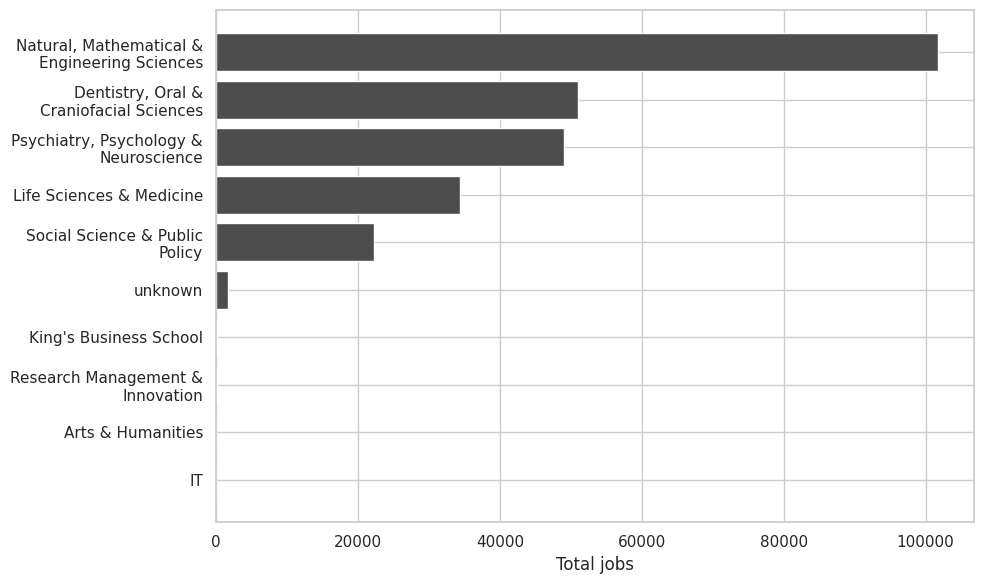

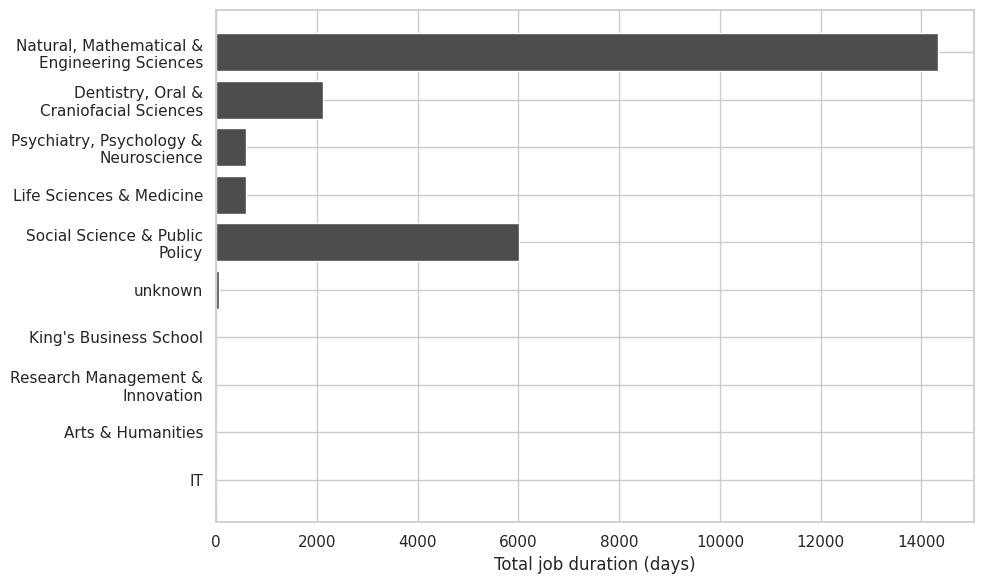

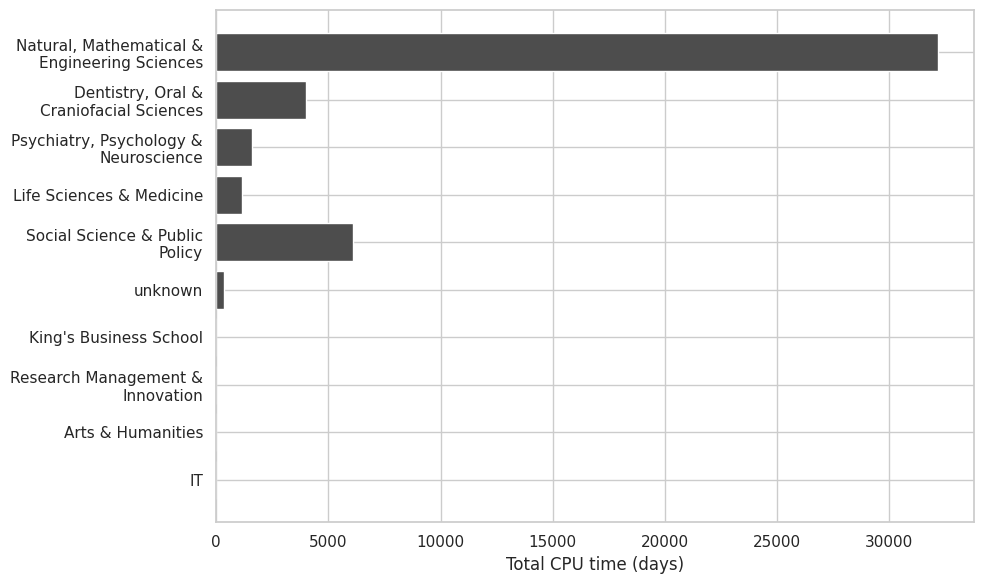

In [4]:
BAR_COLOR = '#4d4d4d'

def overview_bar(values, labels, xlabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, values, color=BAR_COLOR)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

overview_bar(df_plot['job_count'], df_plot['faculty_short'], 'Total jobs')
overview_bar(df_plot['total_elapsed_sec'] / 86400, df_plot['faculty_short'], 'Total job duration (days)')
overview_bar(df_plot['total_cpu_sec'] / 86400, df_plot['faculty_short'], 'Total CPU time (days)')

---
# 2. Global Stats

Key cluster-wide metrics using **weighted efficiency** (total used / total allocated).

In [5]:
def create_summary():
    total_jobs = df_faculties['job_count'].sum()
    total_success = df_faculties['job_count_success'].sum()
    success_rate = (total_success / total_jobs * 100) if total_jobs > 0 else 0
    
    if len(df_global) > 0:
        global_cpu_eff = df_global[CPU_EFF_COL].values[0]
        global_mem_eff = df_global[MEM_EFF_COL].values[0]
    else:
        global_cpu_eff = df_faculties[CPU_EFF_COL].mean()
        global_mem_eff = df_faculties[MEM_EFF_COL].mean()
    
    if HAS_JOB_DATA and 'wait_sec' in df_jobs.columns:
        median_wait = df_jobs['wait_sec'].median() / 60
    else:
        median_wait = df_faculties['avg_wait_sec'].median() / 60
    
    summary = f"""
## Cluster-Wide Summary (Weighted Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | {total_jobs:,} |
| **Success Rate** | {success_rate:.1f}% |
| **CPU Efficiency** (weighted) | {global_cpu_eff:.1f}% |
| **Memory Efficiency** (weighted) | {global_mem_eff:.1f}% |
| **Median Queue Wait** | {median_wait:.1f} min |

*Weighted efficiency = total resources used / total resources allocated. Larger jobs contribute more.*
"""
    display(Markdown(summary))

create_summary()


## Cluster-Wide Summary (Weighted Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | 260,243 |
| **Success Rate** | 71.2% |
| **CPU Efficiency** (weighted) | 41.1% |
| **Memory Efficiency** (weighted) | 320.3% |
| **Median Queue Wait** | 24.1 min |

*Weighted efficiency = total resources used / total resources allocated. Larger jobs contribute more.*


In [6]:
def efficiency_ranking():
    ranking = df_faculties[['faculty', 'job_count', CPU_EFF_COL, MEM_EFF_COL, 'job_count_failed']].copy()
    ranking['failure_rate'] = (ranking['job_count_failed'] / ranking['job_count'] * 100).round(1)
    ranking = ranking.sort_values(CPU_EFF_COL, ascending=False)
    
    display(Markdown("### Faculty Ranking by Weighted CPU Efficiency"))
    display(Markdown("*Weighted efficiency shows overall resource utilisation — faculties with large, inefficient jobs rank lower.*"))
    display(ranking[['faculty', 'job_count', CPU_EFF_COL, MEM_EFF_COL, 'failure_rate']].rename(columns={
        'faculty': 'Faculty', 'job_count': 'Jobs', CPU_EFF_COL: 'CPU Eff %',
        MEM_EFF_COL: 'Mem Eff %', 'failure_rate': 'Failure %'
    }))

efficiency_ranking()

### Faculty Ranking by Weighted CPU Efficiency

*Weighted efficiency shows overall resource utilisation — faculties with large, inefficient jobs rank lower.*

,Faculty,Jobs,CPU Eff %,Mem Eff %,Failure %
4,Faculty of Social Science & Public Policy,22259,96.821064,32.670394,6.2
0,Faculty of Arts & Humanities,36,85.740000,2675.241223,27.8
9,unknown,1594,67.700000,24.877692,11.3
3,"Faculty of Natural, Mathematical & Engineering...",101743,54.890000,20.726439,10.9
6,"Institute of Psychiatry, Psychology & Neurosci...",49056,38.044919,30.350199,15.6
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",51048,34.979521,341.145253,5.0
2,Faculty of Life Sciences & Medicine,34375,18.866169,37.417214,21.0
7,King's Business School,74,13.850000,23.463775,9.5
8,Research Management & Innovation,56,0.020000,16.639060,26.8
5,IT,2,0.010000,0.745112,100.0


**Column definitions:**
- **Jobs**: Total number of jobs submitted by the faculty
- **CPU Eff %**: Weighted CPU efficiency (total CPU time used / total CPU time allocated × 100)
- **Mem Eff %**: Weighted memory efficiency (total memory used / total memory requested × 100)
- **Failure %**: Percentage of all submitted jobs that failed (FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY). CANCELLED jobs are excluded from failure count since cancellation is intentional. Success = COMPLETED only.

**Observations:**

- **Faculty of Social Science & Public Policy**: Excellent CPU efficiency (97%) while submitting a substantial number of jobs (~22k). A model for efficient cluster usage.

- **Faculty of Natural, Mathematical & Engineering Sciences**: Room for improvement at 53% CPU efficiency. They submit the most jobs by far (~89k), which is why they produce the most absolute CPU waste despite not having the worst efficiency rate.

- **Faculty of Arts & Humanities**: High CPU efficiency (84%), but nearly half their jobs failed (43% failure rate), and the sample size is very small (28 jobs). Not statistically representative.

---
# 3. Detailed Analysis

## 3.1 Resource Waste

From an infrastructure perspective, the key question is: **How much cluster capacity is being wasted?**

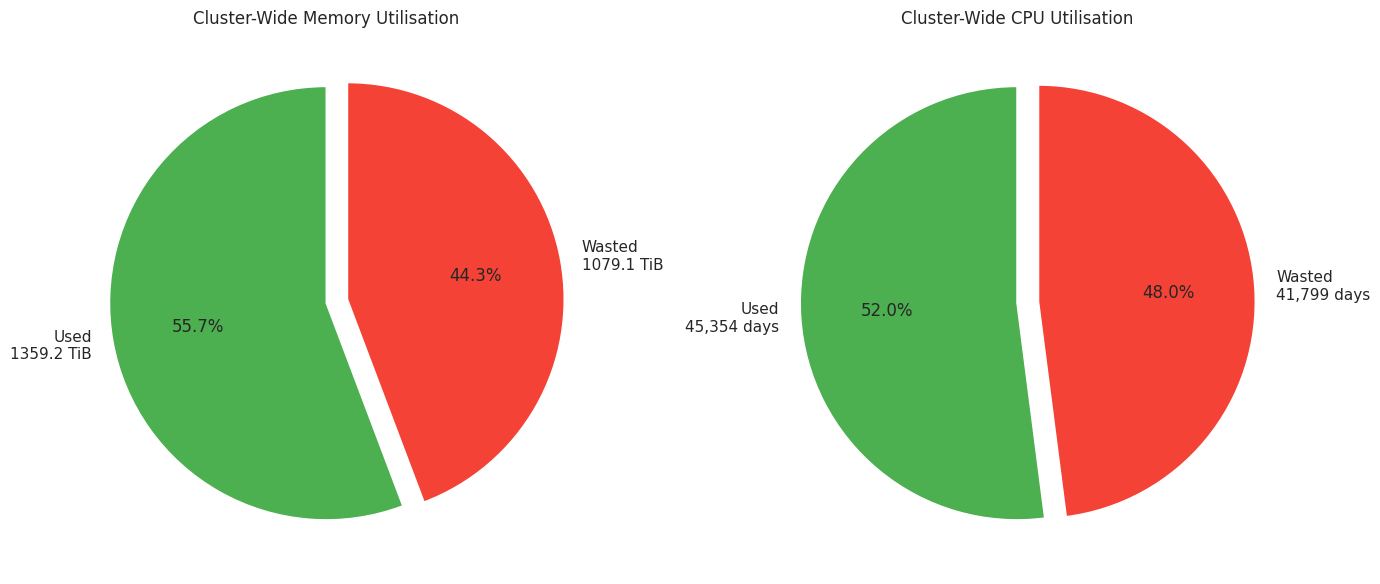

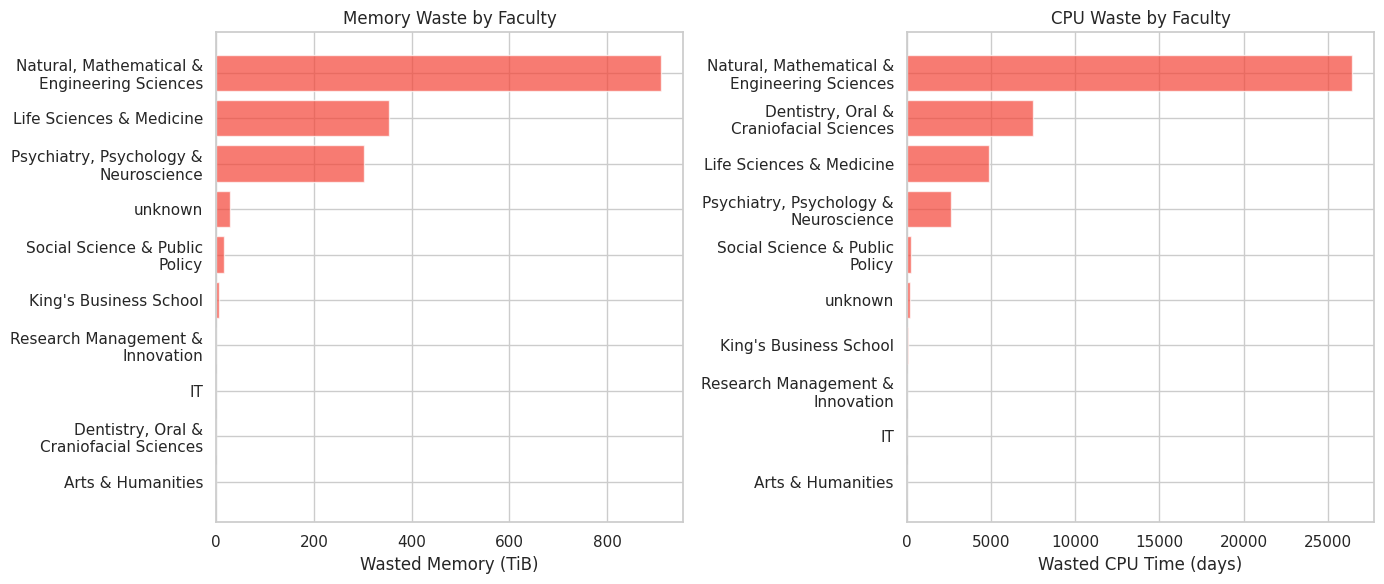

In [7]:
def plot_waste_and_utilisation():
    """Cluster-wide utilisation pies and per-faculty waste bar charts."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Memory utilisation (TiB)
    total_mem_requested = df_faculties['total_reqmem_bytes'].sum() / (1024**4)
    total_mem_used = df_faculties['total_maxrss_bytes'].sum() / (1024**4)
    total_mem_wasted = max(0, total_mem_requested - total_mem_used)

    axes[0].pie([total_mem_used, total_mem_wasted],
                labels=[f'Used\n{total_mem_used:.1f} TiB', f'Wasted\n{total_mem_wasted:.1f} TiB'],
                colors=['#4caf50', '#f44336'], autopct='%1.1f%%',
                startangle=90, explode=(0, 0.1))
    axes[0].set_title('Cluster-Wide Memory Utilisation')

    # CPU utilisation
    cpu_allocated = np.where(
        df_faculties[CPU_EFF_COL] > 0,
        df_faculties['total_cpu_sec'] * 100 / df_faculties[CPU_EFF_COL], 0)
    total_cpu_used = df_faculties['total_cpu_sec'].sum() / 86400
    total_cpu_allocated = cpu_allocated.sum() / 86400
    total_cpu_wasted = max(0, total_cpu_allocated - total_cpu_used)

    axes[1].pie([total_cpu_used, total_cpu_wasted],
                labels=[f'Used\n{total_cpu_used:,.0f} days', f'Wasted\n{total_cpu_wasted:,.0f} days'],
                colors=['#4caf50', '#f44336'], autopct='%1.1f%%',
                startangle=90, explode=(0, 0.1))
    axes[1].set_title('Cluster-Wide CPU Utilisation')

    plt.tight_layout()
    plt.show()

    # Per-faculty waste
    df_faculties['mem_wasted_tib'] = ((df_faculties['total_reqmem_bytes'] -
                                       df_faculties['total_maxrss_bytes']) / (1024**4)).clip(lower=0)
    df_faculties['cpu_wasted_days'] = ((cpu_allocated - df_faculties['total_cpu_sec']) / 86400).clip(lower=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sorted_df = df_faculties.sort_values('mem_wasted_tib', ascending=True)
    axes[0].barh(sorted_df['faculty_short'], sorted_df['mem_wasted_tib'], color='#f44336', alpha=0.7)
    axes[0].set_xlabel('Wasted Memory (TiB)')
    axes[0].set_title('Memory Waste by Faculty')

    sorted_df = df_faculties.sort_values('cpu_wasted_days', ascending=True)
    axes[1].barh(sorted_df['faculty_short'], sorted_df['cpu_wasted_days'], color='#f44336', alpha=0.7)
    axes[1].set_xlabel('Wasted CPU Time (days)')
    axes[1].set_title('CPU Waste by Faculty')

    plt.tight_layout()
    plt.show()

plot_waste_and_utilisation()

## 3.2 Weighted Efficiency by Faculty

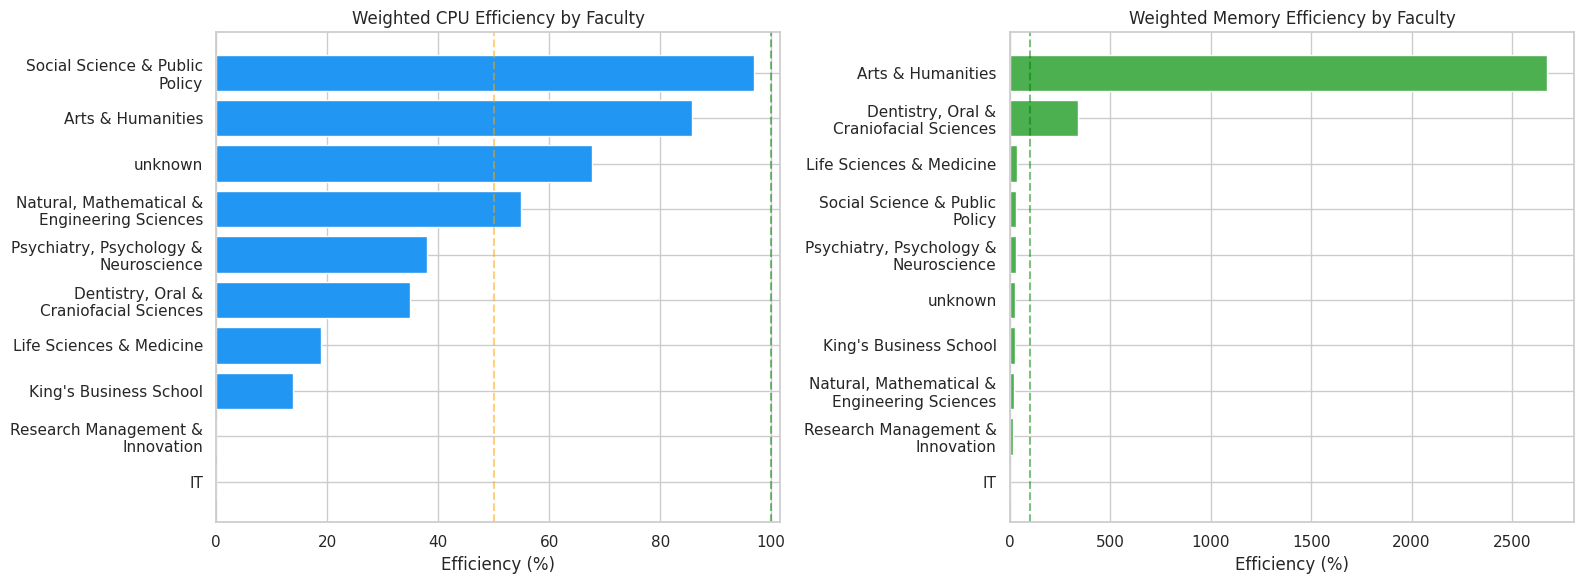

In [8]:
def plot_efficiency():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sorted_df = df_faculties.sort_values(CPU_EFF_COL, ascending=True)
    axes[0].barh(sorted_df['faculty_short'], sorted_df[CPU_EFF_COL], color='#2196f3')
    axes[0].set_xlabel('Efficiency (%)')
    axes[0].set_title('Weighted CPU Efficiency by Faculty')
    axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    axes[0].axvline(x=50, color='orange', linestyle='--', alpha=0.5)
    
    sorted_df = df_faculties.sort_values(MEM_EFF_COL, ascending=True)
    axes[1].barh(sorted_df['faculty_short'], sorted_df[MEM_EFF_COL], color='#4caf50')
    axes[1].set_xlabel('Efficiency (%)')
    axes[1].set_title('Weighted Memory Efficiency by Faculty')
    axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_efficiency()

## 3.3 Job Success/Failure by Faculty

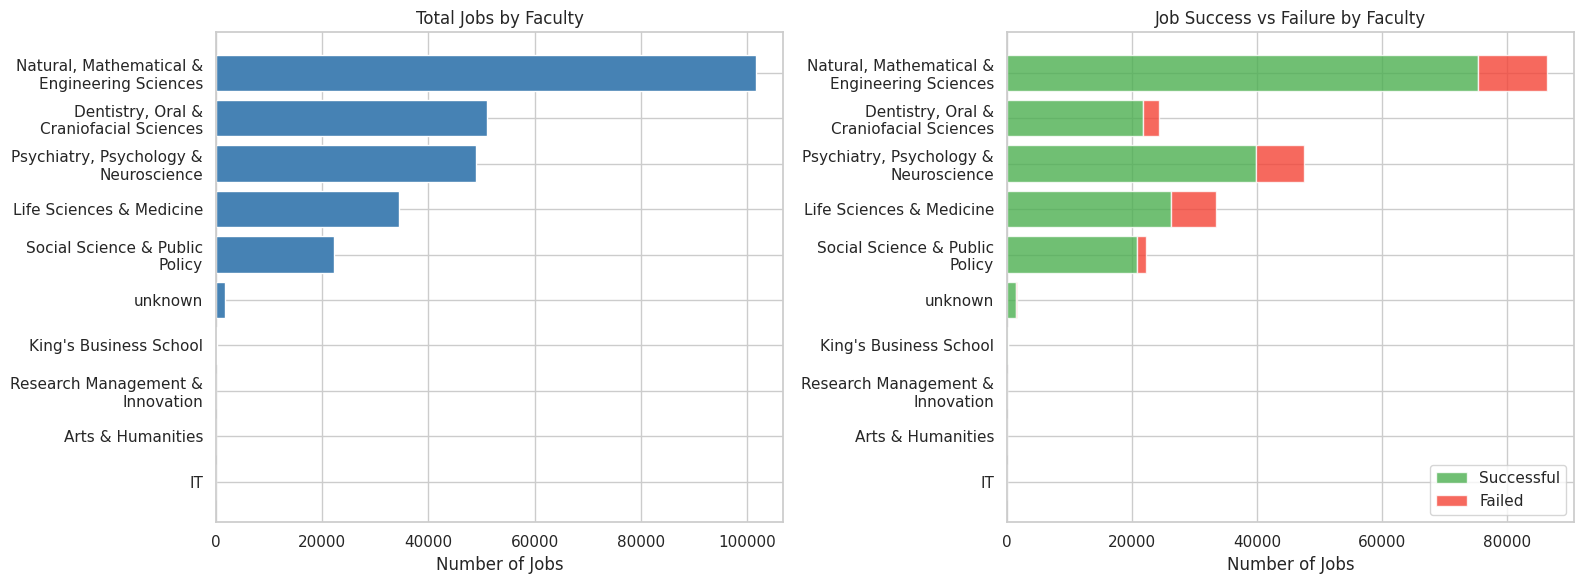

In [9]:
def plot_job_counts():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sorted_df = df_faculties.sort_values('job_count', ascending=True)
    
    axes[0].barh(sorted_df['faculty_short'], sorted_df['job_count'], color='steelblue')
    axes[0].set_xlabel('Number of Jobs')
    axes[0].set_title('Total Jobs by Faculty')
    
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_success'], 
                 label='Successful', color='#4caf50', alpha=0.8)
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_failed'], 
                 left=sorted_df['job_count_success'], label='Failed', color='#f44336', alpha=0.8)
    axes[1].set_xlabel('Number of Jobs')
    axes[1].set_title('Job Success vs Failure by Faculty')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

plot_job_counts()

---
# 4. Correlation Analysis

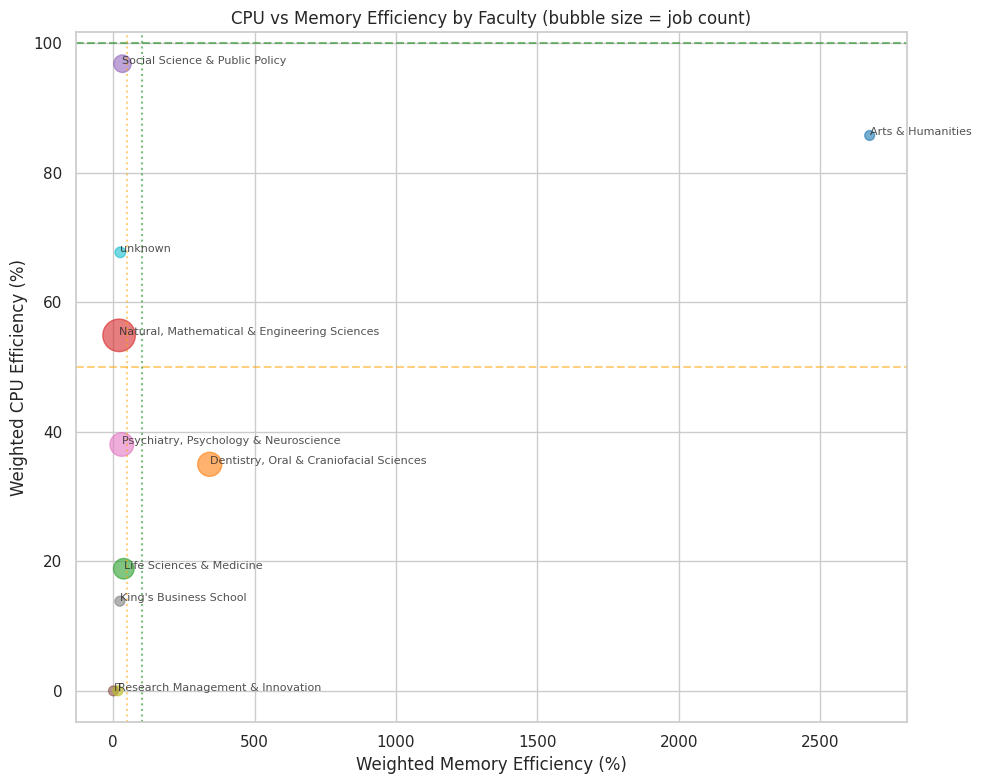

In [10]:
def cpu_memory_scatter():
    """Scatter plot: CPU vs Memory efficiency by faculty."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    plot_df = df_faculties.dropna(subset=[CPU_EFF_COL, MEM_EFF_COL])
    
    ax.scatter(plot_df[MEM_EFF_COL], plot_df[CPU_EFF_COL],
               s=plot_df['job_count']/plot_df['job_count'].max()*500+50,
               alpha=0.6, c=range(len(plot_df)), cmap='tab10')
    
    for idx, row in plot_df.iterrows():
        ax.annotate(row['faculty_short'].replace('\n', ' '),
                    (row[MEM_EFF_COL], row[CPU_EFF_COL]),
                   fontsize=8, alpha=0.8)
    
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5)
    ax.axhline(y=100, color='green', linestyle='--', alpha=0.5)
    ax.axvline(x=50, color='orange', linestyle=':', alpha=0.5)
    ax.axvline(x=100, color='green', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Weighted Memory Efficiency (%)')
    ax.set_ylabel('Weighted CPU Efficiency (%)')
    ax.set_title('CPU vs Memory Efficiency by Faculty (bubble size = job count)')
    plt.tight_layout()
    plt.show()

cpu_memory_scatter()

---
# 5. Technical Appendix

## Data Sources

- **Job data:** Slurm accounting database (MySQL), accessed directly via `mysql.connector` (not via `sacct`, for reliability).
  - `create_job_table`: job metadata — timestamps, resource requests (`cpus_req`, `tres_req`), state, time limit
  - `create_step_table`: per-step CPU time (`user_sec`, `sys_sec`) and peak memory usage (`tres_usage_in_max`)
  - `create_assoc_table`: maps job associations to usernames
- **Faculty mapping:** Active Directory via LDAP. Each username is looked up to retrieve its faculty attribute (`st`).

## Efficiency Metrics

### Weighted vs Average

This notebook uses **weighted efficiency** — total resources used divided by total resources allocated. Larger jobs contribute more because they consume more cluster capacity.

| Version | Formula | Question it answers |
|---------|---------|---------------------|
| **Weighted** | Sum(used) / Sum(allocated) × 100 | "How efficiently are allocated resources being used overall?" Larger jobs contribute more. |
| **Average** | Mean(per-job efficiency) | "What's the typical job's efficiency?" Each job counts equally. |

For user-focused analysis (where each job counts equally), see `visualisation_users.ipynb`.

### CPU Efficiency

`CPU Efficiency = TotalCPU / (Elapsed × CPUs) × 100`

- **TotalCPU** = user-mode CPU seconds + system-mode CPU seconds + microsecond fractions.
- **CPUs** = either `cpus_req` (requested) or `alloc_cpus` (allocated) from the job table.

**Why efficiency based on requested CPUs can exceed 100%:**
- Code uses more threads than requested (under-requesting)
- Slurm allocates more CPUs than requested due to core-level allocation

**Requested vs allocated CPUs:** The cluster uses `CR_CORE_MEMORY` allocation (`SelectTypeParameters`), meaning Slurm allocates whole cores. On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads. The `alloc_cpus` field stores hardware threads, so `alloc_cpus` can be 2× `req_cpus`.

**Why efficiency based on allocated CPUs can still exceed 100%:** With `ConstrainCores` enabled, jobs are restricted to their allocated cores, so efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood — possibly related to multi-node job accounting or other Slurm internals.

### Memory Efficiency

`Memory Efficiency = MaxRSS / ReqMem × 100`

- **MaxRSS**: Peak memory usage across all steps.
- **ReqMem**: Requested memory (always stored as total memory regardless of how it was requested).

**Why it can exceed 100%:** The data in this analysis is from a period when memory limits were **not enforced** (`ConstrainRAMSpace` was disabled). Jobs could exceed requested memory without being killed. Memory enforcement has since been enabled — new jobs exceeding their memory request will be terminated.

### Time Efficiency

`Time Efficiency = Elapsed / (Timelimit × 60) × 100`

Measures what fraction of the requested wall-clock time was actually used.

## Resource Enforcement (cgroups)

Slurm can enforce resource limits using Linux cgroups:

| Resource | Setting | Status | Effect |
|----------|---------|--------|--------|
| Memory | `ConstrainRAMSpace` | Now enabled | Jobs killed if exceeding request |
| CPU | `ConstrainCores` | Enabled | Jobs restricted to allocated cores |

With `ConstrainCores` enabled, jobs are restricted to their allocated cores.

## Job States Included

Only jobs in specific terminal states are included:

| State | Included | Why |
|-------|----------|-----|
| COMPLETED | **Yes** | Clean efficiency data |
| TIMEOUT | **Yes** | Job ran its full requested time |
| OUT_OF_MEMORY | **Yes** | Shows memory under-requesting |
| CANCELLED, FAILED, NODE_FAIL, PREEMPTED | No | Incomplete, potentially misleading |

**Success/Failure Metrics:** Computed across ALL job states:
- Success = COMPLETED only
- Failed = FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY
- CANCELLED is excluded from failure count (intentional user action)

**Efficiency Metrics:** Only computed for COMPLETED, TIMEOUT, and OUT_OF_MEMORY jobs (which ran long enough to have meaningful resource usage data).

## CPU Time and Step Handling

Slurm records CPU time per step within each job. For jobs using `srun`, the batch step records only shell overhead, while the srun steps carry the actual computation. The SQL query sums only regular steps, falling back to the batch step for jobs that have no `srun` steps.

## Faculty Merging

Four pairs of historically different names for the same faculty are merged before analysis:

| Old name | Merged into |
|----------|-------------|
| Faculty of Life Sciences and Medicine | Faculty of Life Sciences & Medicine |
| IoPPN | Institute of Psychiatry, Psychology & Neuroscience |
| Dentistry, Oral & Craniofacial Sciences | Faculty of Dentistry, Oral & Craniofacial Sciences |
| Social Science & Public Policy | Faculty of Social Science & Public Policy |

In [11]:
display(Markdown("### Raw Faculty Data"))
display(df_faculties)

### Raw Faculty Data

,faculty,job_count,job_count_success,job_count_failed,count_timeout,count_out_of_memory,total_elapsed_sec,total_cpu_sec,total_user_cpu_sec,total_sys_cpu_sec,...,weighted_cpu_eff_alloc,weighted_mem_eff,weighted_time_eff,avg_cpu_eff_req,avg_cpu_eff_alloc,avg_mem_eff,avg_time_eff,faculty_short,mem_wasted_tib,cpu_wasted_days
0,Faculty of Arts & Humanities,36,16,10,0,0,3.227400e+04,2.767091e+04,2.301828e+04,4652.63,...,43.860000,2675.241223,2.640000,79.440000,40.470000,7387.330000,2.420000,Arts & Humanities,0.000000,0.053265
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",51048,21742,2555,102,0,1.829563e+08,3.466677e+08,3.057421e+08,40925589.25,...,34.135554,341.145253,9.771489,72.081982,64.227346,327.835822,9.485175,"Dentistry, Oral &\nCraniofacial Sciences",0.000000,7458.232362
2,Faculty of Life Sciences & Medicine,34375,26235,7226,254,0,5.141890e+07,9.795547e+07,9.184888e+07,6106587.50,...,16.208193,37.417214,NaN,58.005976,57.756880,73.503062,6.089259,Life Sciences & Medicine,354.420917,4875.657631
3,"Faculty of Natural, Mathematical & Engineering...",101743,75235,11092,1788,0,1.237971e+09,2.779333e+09,2.727891e+09,51441924.14,...,54.400000,20.726439,NaN,74.460000,72.780000,50.350000,33.600000,"Natural, Mathematical &\nEngineering Sciences",909.996856,26436.652255
4,Faculty of Social Science & Public Policy,22259,20752,1382,64,0,5.195569e+08,5.259406e+08,5.227838e+08,3156813.00,...,96.665409,32.670394,14.793900,88.722498,88.626361,34.105935,15.052391,Social Science & Public\nPolicy,15.285339,199.864129
5,IT,2,0,2,2,0,3.456090e+05,1.821000e+01,1.316000e+01,5.05,...,NaN,0.745112,100.000000,0.010000,0.000000,0.750000,100.000000,IT,0.124069,2.107428
6,"Institute of Psychiatry, Psychology & Neurosci...",49056,39798,7639,233,0,5.152484e+07,1.391147e+08,1.222030e+08,16911688.83,...,35.717641,30.350199,0.035039,50.954310,49.097084,131.309530,6.633909,"Psychiatry, Psychology &\nNeuroscience",302.501543,2622.041705
7,King's Business School,74,64,7,1,0,9.932300e+04,3.562552e+05,3.392198e+05,17035.33,...,13.850000,23.463775,3.530000,6.230000,6.230000,25.030000,4.030000,King's Business School,4.906092,25.647967
8,Research Management & Innovation,56,13,15,11,0,1.067570e+05,3.029400e+02,2.316100e+02,71.33,...,0.020000,16.639060,59.710000,7.190000,5.170000,8.700000,52.150000,Research Management &\nInnovation,0.214082,17.527744
9,unknown,1594,1348,180,19,0,4.643937e+06,2.916878e+07,2.888657e+07,282208.72,...,64.200000,24.877692,NaN,35.020000,21.330000,72.110000,3.130000,unknown,28.563666,161.071354


## Aggregate Stats Column Reference

| Column | Description |
|--------|-------------|
| `faculty` | Faculty name (from LDAP lookup) |
| `job_count` | Total jobs submitted (all states) |
| `job_count_success` | Jobs that completed successfully (COMPLETED state only) |
| `job_count_failed` | Jobs that failed (FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY) |
| `count_timeout` | Jobs that hit their time limit |
| `count_out_of_memory` | Jobs killed for exceeding memory |
| `total_elapsed_sec` | Sum of wall-clock time across efficiency jobs |
| `avg_elapsed_sec` | Mean wall-clock time per efficiency job |
| `total_cpu_sec` | Sum of CPU time (user + system) across efficiency jobs |
| `avg_cpu_sec` | Mean CPU time per efficiency job |
| `total_user_cpu_sec` | CPU time in user mode (application code) |
| `total_sys_cpu_sec` | CPU time in system mode (kernel/OS operations) |
| `user_cpu_pct` | Percentage of CPU time in user mode |
| `sys_cpu_pct` | Percentage of CPU time in system mode |
| `total_maxrss_bytes` | Sum of peak memory usage |
| `avg_maxrss_bytes` | Mean peak memory usage per job |
| `total_reqmem_bytes` | Sum of requested memory |
| `avg_reqmem_bytes` | Mean requested memory per job |
| `total_reqcpus` | Sum of requested CPUs |
| `avg_reqcpus` | Mean requested CPUs per job |
| `total_nodes` | Sum of nodes used |
| `total_wait_sec` | Sum of queue wait time |
| `avg_wait_sec` | Mean queue wait time per job |
| `weighted_cpu_eff_req` | CPU efficiency based on requested CPUs: total_cpu / (elapsed × req_cpus) |
| `avg_cpu_eff_req` | Mean of per-job CPU efficiency (requested) |
| `weighted_cpu_eff_alloc` | CPU efficiency based on allocated CPUs |
| `avg_cpu_eff_alloc` | Mean of per-job CPU efficiency (allocated) |
| `weighted_mem_eff` | Memory efficiency: total_maxrss / total_reqmem |
| `avg_mem_eff` | Mean of per-job memory efficiency |
| `weighted_time_eff` | Time efficiency: total_elapsed / total_timelimit |
| `avg_time_eff` | Mean of per-job time efficiency |

*Note: Resource totals/averages and efficiency metrics are computed from efficiency jobs only (COMPLETED + TIMEOUT + OUT_OF_MEMORY).*

In [12]:
# Sanity Check: CPU Efficiency - Requested vs Allocated CPUs
display(Markdown("## CPU Efficiency: Requested vs Allocated"))
display(Markdown("""
This compares CPU efficiency calculated using:
- **Requested CPUs** (`req_cpus`): What users asked for
- **Allocated CPUs** (`alloc_cpus`): Hardware threads allocated by Slurm

**Cluster configuration:** `SelectTypeParameters = CR_CORE_MEMORY`
- Slurm allocates whole cores, not individual hardware threads
- On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads
- `alloc_cpus` stores hardware threads, so it can be 2× `req_cpus`

**Why >100% in single jobs still appears with allocated CPUs:** With `ConstrainCores` enabled, efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood.
"""))

# Global stats
display(Markdown("### Global Stats"))
global_df = pd.read_csv(FACULTY_STATS_PATH)
global_df = global_df[global_df['faculty'].str.strip('"') == 'all']
if len(global_df) > 0:
    global_comparison = pd.DataFrame({
        'Metric': ['Weighted CPU Efficiency'],
        'Based on Requested': [f"{global_df['weighted_cpu_eff_req'].values[0]:.1f}%"],
        'Based on Allocated': [f"{global_df['weighted_cpu_eff_alloc'].values[0]:.1f}%"]
    })
    display(global_comparison)
else:
    print("No global stats found. Run aggregate_stats with --collate_by none to generate.")

# Faculty stats
display(Markdown("### By Faculty"))
cols_to_show = ['faculty', 'job_count', 'weighted_cpu_eff_req', 'weighted_cpu_eff_alloc']
cols_available = [c for c in cols_to_show if c in df_faculties.columns]
if 'weighted_cpu_eff_alloc' in cols_available:
    comparison_df = df_faculties[cols_available].copy()
    comparison_df = comparison_df.sort_values('job_count', ascending=False)
    display(comparison_df.round(1))
else:
    print("Allocated CPU efficiency columns not found in data.")

## CPU Efficiency: Requested vs Allocated


This compares CPU efficiency calculated using:
- **Requested CPUs** (`req_cpus`): What users asked for
- **Allocated CPUs** (`alloc_cpus`): Hardware threads allocated by Slurm

**Cluster configuration:** `SelectTypeParameters = CR_CORE_MEMORY`
- Slurm allocates whole cores, not individual hardware threads
- On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads
- `alloc_cpus` stores hardware threads, so it can be 2× `req_cpus`

**Why >100% in single jobs still appears with allocated CPUs:** With `ConstrainCores` enabled, efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood.


### Global Stats

No global stats found. Run aggregate_stats with --collate_by none to generate.


### By Faculty

,faculty,job_count,weighted_cpu_eff_req,weighted_cpu_eff_alloc
3,"Faculty of Natural, Mathematical & Engineering...",101743,54.9,54.4
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",51048,35.0,34.1
6,"Institute of Psychiatry, Psychology & Neurosci...",49056,38.0,35.7
2,Faculty of Life Sciences & Medicine,34375,18.9,16.2
4,Faculty of Social Science & Public Policy,22259,96.8,96.7
9,unknown,1594,67.7,64.2
7,King's Business School,74,13.8,13.8
8,Research Management & Innovation,56,0.0,0.0
0,Faculty of Arts & Humanities,36,85.7,43.9
5,IT,2,0.0,NaN


In [13]:
if HAS_JOB_DATA:
    display(Markdown("### Sample Job-Level Data"))
    display(Markdown(f"Showing first 10 rows of {len(df_jobs):,} jobs:"))
    display(df_jobs.drop(columns=['username']).head(10))

### Sample Job-Level Data

Showing first 10 rows of 187,677 jobs:

,job_id,faculty,submission_type,step_count,state,exit_code,is_success,elapsed_sec,wait_sec,timelimit_sec,...,user_cpu_sec,sys_cpu_sec,user_cpu_pct,maxrss_bytes,reqmem_bytes,req_cpus,alloc_cpus,n_nodes,n_tasks,faculty_short
0,28235866,"Faculty of Natural, Mathematical & Engineering...",batch,1,6,0,0,86408.0,34480.0,86400,...,0.23,0.06,80.31,115847168,34359738368,1,2,1,1,"Natural, Mathematical &\nEngineering Sciences"
1,28235867,"Faculty of Natural, Mathematical & Engineering...",batch,1,6,0,0,86403.0,53165.0,86400,...,0.25,0.08,75.36,129310720,34359738368,1,2,1,1,"Natural, Mathematical &\nEngineering Sciences"
2,28235868,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,25.0,30.0,36000,...,0.20,0.58,26.22,155648,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"
3,28235869,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,23.0,31.0,36000,...,0.21,0.62,25.47,466944,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"
4,28235870,"Faculty of Dentistry, Oral & Craniofacial Scie...",batch,1,3,0,1,64709.0,24.0,86400,...,64222.97,73.75,99.89,1097084928,1048576000,1,1,1,1,"Dentistry, Oral &\nCraniofacial Sciences"
5,28235871,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,31.0,36000,...,0.20,0.59,25.26,233472,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"
6,28235872,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,30.0,36000,...,0.21,0.61,25.62,495616,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"
7,28235873,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,30.0,36000,...,0.21,0.57,27.23,102400,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"
8,28235874,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,30.0,36000,...,0.21,0.61,25.71,94208,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"
9,28235875,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,30.0,36000,...,0.21,0.58,26.61,331776,8388608000,8,8,1,1,"Psychiatry, Psychology &\nNeuroscience"


## Job-Level Column Reference

| Column | Description |
|--------|-------------|
| `job_id` | Slurm job ID |
| `username` | User who submitted the job |
| `faculty` | Faculty (if `--include-faculty` used) |
| `submission_type` | How job was submitted: batch, interactive, or unknown |
| `step_count` | Number of job steps |
| `state` | Slurm state code (3=COMPLETED, 6=TIMEOUT, 11=OUT_OF_MEMORY) |
| `exit_code` | Exit code from the job |
| `is_success` | 1 if COMPLETED, 0 otherwise |
| `elapsed_sec` | Wall-clock runtime in seconds |
| `wait_sec` | Queue wait time in seconds |
| `timelimit_sec` | Requested time limit in seconds |
| `cpu_eff_req` | CPU efficiency based on requested CPUs (%) |
| `cpu_eff_alloc` | CPU efficiency based on allocated CPUs (%) |
| `mem_eff` | Memory efficiency (%) |
| `time_eff` | Time efficiency: elapsed / timelimit (%) |
| `total_cpu_sec` | Total CPU time (user + system) |
| `user_cpu_sec` | CPU time in user mode |
| `sys_cpu_sec` | CPU time in system mode |
| `user_cpu_pct` | Percentage of CPU time in user mode |
| `maxrss_bytes` | Peak memory usage (bytes) |
| `reqmem_bytes` | Requested memory (bytes) |
| `req_cpus` | Number of CPUs requested |
| `alloc_cpus` | Number of CPUs allocated by Slurm |
| `n_nodes` | Number of nodes used |
| `n_tasks` | Number of tasks |